<a href="https://colab.research.google.com/github/huangste/macro-regime-classifier/blob/main/Regime_Model_v2_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install yfinance
!pip install pandas-datareader

In [5]:
import yfinance as yf
import pandas as pd
import pandas_datareader.data as web
import datetime

#download asstes ex rates from yfinance and download rates from Fred

equity = ["^GSPC", "^N225", "^NDX"]
fx = ["DX-Y.NYB", "JPY=X"]
commodities = ["GC=F", "CL=F"]
credit = ["HYG"]

def get_data(tickers):
    data=yf.download(tickers, start='1990-01-01', auto_adjust=True,  progress=False, threads=False)
    close = data["Close"]

    if isinstance(close, pd.Series):
        close = close.to_frame()
    return close

eq = get_data(equity)
fx = get_data(fx)
cmd = get_data(commodities)
cred = get_data(credit)



start = datetime.datetime(1990, 1, 1)
end = datetime.datetime.today()

rates = web.DataReader(['DGS10', 'DGS2'], 'fred', start, end)
rates.head(5)



,DGS10,DGS2
DATE,,
1990-01-01,NaN,NaN
1990-01-02,7.94,7.87
1990-01-03,7.99,7.94
1990-01-04,7.98,7.92
1990-01-05,7.99,7.90


In [6]:
# Rename columns clearly
eq.columns = ["SPX", "Nikkei", "NDX"]
fx.columns = ["DXY", "USDJPY"]
cmd.columns = ["Gold", "Oil"]
cred.columns = ["HYG"]

# Create yield curve slope
rates["US_10Y_2Y_Slope"] = rates["DGS10"] - rates["DGS2"]

# Combine all assets
raw_data = pd.concat(
    [
        eq,
        fx,
        cmd,
        rates[["DGS10", "DGS2", "US_10Y_2Y_Slope"]]
    ],
    axis=1
).sort_index()

# Forward-fill rates because FRED has holidays / missing days
raw_data = raw_data.ffill()
raw_data.isna().sum()
# Drop remaining rows with missing data
raw_data = raw_data.dropna()
raw_data.describe().round(2)


,SPX,Nikkei,NDX,DXY,USDJPY,Gold,Oil,DGS10,DGS2,US_10Y_2Y_Slope
count,6703.00,6703.00,6703.00,6703.00,6703.00,6703.00,6703.00,6703.00,6703.00,6703.00
mean,2354.33,18760.00,6247.05,92.58,113.12,64.82,1298.06,3.26,2.17,1.09
std,1552.63,9990.08,6363.68,11.13,18.89,24.59,834.74,1.22,1.65,0.95
min,676.53,7054.98,804.64,71.33,75.74,-37.63,255.10,0.52,0.09,-1.08
25%,1207.05,10879.62,1721.56,82.59,103.76,46.52,651.60,2.23,0.65,0.26
50%,1650.34,16101.91,3142.54,93.14,110.92,63.82,1252.20,3.39,1.77,1.08
75%,2991.09,22754.84,8215.16,99.55,120.40,82.20,1708.25,4.27,3.71,1.89
max,7392.87,62833.84,29188.89,120.90,161.62,145.29,5318.40,5.91,6.24,2.91


In [7]:
# % returns for price series
returns = raw_data.pct_change()

# for rates, better to use change (not %)
rates_cols = ["DGS10", "DGS2", "US_10Y_2Y_Slope"]
returns[rates_cols] = raw_data[rates_cols].diff()

# clean
returns = returns.dropna()


features = pd.DataFrame(index=raw_data.index)

price_cols = ["SPX", "Nikkei", "NDX", "DXY", "USDJPY", "Gold", "Oil"]
rate_cols = ["DGS10", "DGS2", "US_10Y_2Y_Slope"]

# price assets: returns over different horizons
for col in price_cols:
    features[f"{col}_1d_ret"] = raw_data[col].pct_change(1)
    features[f"{col}_10d_ret"] = raw_data[col].pct_change(10)
    features[f"{col}_21d_ret"] = raw_data[col].pct_change(21)
    features[f"{col}_63d_ret"] = raw_data[col].pct_change(63)

# rates: changes, not pct returns
for col in rate_cols:
    features[f"{col}_1d_chg"] = raw_data[col].diff(1)
    features[f"{col}_10d_chg"] = raw_data[col].diff(10)
    features[f"{col}_21d_chg"] = raw_data[col].diff(21)
    features[f"{col}_63d_chg"] = raw_data[col].diff(63)

# volatility features using 1d returns
daily_ret = raw_data[price_cols].pct_change(1)

for col in price_cols:
    features[f"{col}_21d_vol"] = daily_ret[col].rolling(21).std()
    features[f"{col}_63d_vol"] = daily_ret[col].rolling(63).std()

features = features.dropna()
print(features.columns)
print(features.shape)
display(features.head().style.format("{:.3%}"))




Index(['SPX_1d_ret', 'SPX_10d_ret', 'SPX_21d_ret', 'SPX_63d_ret',
       'Nikkei_1d_ret', 'Nikkei_10d_ret', 'Nikkei_21d_ret', 'Nikkei_63d_ret',
       'NDX_1d_ret', 'NDX_10d_ret', 'NDX_21d_ret', 'NDX_63d_ret', 'DXY_1d_ret',
       'DXY_10d_ret', 'DXY_21d_ret', 'DXY_63d_ret', 'USDJPY_1d_ret',
       'USDJPY_10d_ret', 'USDJPY_21d_ret', 'USDJPY_63d_ret', 'Gold_1d_ret',
       'Gold_10d_ret', 'Gold_21d_ret', 'Gold_63d_ret', 'Oil_1d_ret',
       'Oil_10d_ret', 'Oil_21d_ret', 'Oil_63d_ret', 'DGS10_1d_chg',
       'DGS10_10d_chg', 'DGS10_21d_chg', 'DGS10_63d_chg', 'DGS2_1d_chg',
       'DGS2_10d_chg', 'DGS2_21d_chg', 'DGS2_63d_chg',
       'US_10Y_2Y_Slope_1d_chg', 'US_10Y_2Y_Slope_10d_chg',
       'US_10Y_2Y_Slope_21d_chg', 'US_10Y_2Y_Slope_63d_chg', 'SPX_21d_vol',
       'SPX_63d_vol', 'Nikkei_21d_vol', 'Nikkei_63d_vol', 'NDX_21d_vol',
       'NDX_63d_vol', 'DXY_21d_vol', 'DXY_63d_vol', 'USDJPY_21d_vol',
       'USDJPY_63d_vol', 'Gold_21d_vol', 'Gold_63d_vol', 'Oil_21d_vol',
       'Oil_63d

,SPX_1d_ret,SPX_10d_ret,SPX_21d_ret,SPX_63d_ret,Nikkei_1d_ret,Nikkei_10d_ret,Nikkei_21d_ret,Nikkei_63d_ret,NDX_1d_ret,NDX_10d_ret,NDX_21d_ret,NDX_63d_ret,DXY_1d_ret,DXY_10d_ret,DXY_21d_ret,DXY_63d_ret,USDJPY_1d_ret,USDJPY_10d_ret,USDJPY_21d_ret,USDJPY_63d_ret,Gold_1d_ret,Gold_10d_ret,Gold_21d_ret,Gold_63d_ret,Oil_1d_ret,Oil_10d_ret,Oil_21d_ret,Oil_63d_ret,DGS10_1d_chg,DGS10_10d_chg,DGS10_21d_chg,DGS10_63d_chg,DGS2_1d_chg,DGS2_10d_chg,DGS2_21d_chg,DGS2_63d_chg,US_10Y_2Y_Slope_1d_chg,US_10Y_2Y_Slope_10d_chg,US_10Y_2Y_Slope_21d_chg,US_10Y_2Y_Slope_63d_chg,SPX_21d_vol,SPX_63d_vol,Nikkei_21d_vol,Nikkei_63d_vol,NDX_21d_vol,NDX_63d_vol,DXY_21d_vol,DXY_63d_vol,USDJPY_21d_vol,USDJPY_63d_vol,Gold_21d_vol,Gold_63d_vol,Oil_21d_vol,Oil_63d_vol
2000-11-27 00:00:00,0.537%,-0.169%,-2.219%,-10.224%,2.829%,0.380%,0.948%,-12.906%,-2.147%,-2.373%,-12.784%,-30.222%,-1.165%,1.210%,-0.247%,4.423%,-0.593%,2.818%,1.880%,3.714%,-0.056%,2.759%,8.196%,5.928%,1.427%,2.194%,2.156%,-1.387%,1.000%,-13.000%,-8.000%,-17.000%,0.000%,-4.000%,-8.000%,-38.000%,1.000%,-9.000%,0.000%,21.000%,1.306%,1.261%,1.438%,1.320%,3.832%,3.417%,0.517%,0.581%,0.471%,0.445%,1.114%,2.796%,0.371%,0.635%
2000-11-28 00:00:00,-0.955%,-3.388%,-4.474%,-11.965%,-0.418%,-0.008%,1.343%,-13.062%,-5.352%,-13.765%,-14.929%,-35.719%,-0.444%,0.310%,-0.571%,3.535%,-0.362%,1.858%,1.110%,3.281%,-3.194%,-1.722%,4.389%,3.474%,-0.111%,1.850%,2.081%,-3.054%,-5.000%,-17.000%,-15.000%,-14.000%,-7.000%,-13.000%,-18.000%,-39.000%,2.000%,-4.000%,3.000%,25.000%,1.273%,1.256%,1.429%,1.320%,3.940%,3.444%,0.525%,0.583%,0.475%,0.448%,1.360%,2.824%,0.372%,0.600%
2000-11-29 00:00:00,0.437%,-3.445%,-6.119%,-11.760%,-1.032%,-1.970%,-0.220%,-13.334%,-0.697%,-15.401%,-20.700%,-36.505%,0.026%,0.223%,-0.034%,4.658%,1.044%,2.354%,2.326%,5.068%,1.109%,-2.725%,5.935%,3.745%,-1.260%,0.490%,0.566%,-3.827%,-4.000%,-17.000%,-22.000%,-13.000%,-10.000%,-21.000%,-25.000%,-40.000%,6.000%,4.000%,3.000%,27.000%,1.159%,1.257%,1.445%,1.323%,3.576%,3.441%,0.513%,0.565%,0.519%,0.455%,1.367%,2.826%,0.474%,0.617%
2000-11-30 00:00:00,-2.011%,-4.181%,-7.477%,-13.534%,0.971%,0.421%,-1.505%,-12.222%,-3.700%,-14.311%,-22.284%,-38.854%,-1.175%,-1.445%,-0.277%,3.428%,-0.853%,1.406%,1.958%,3.917%,-2.397%,-3.566%,1.807%,1.258%,1.389%,1.618%,2.349%,-2.491%,-7.000%,-20.000%,-26.000%,-20.000%,-8.000%,-26.000%,-27.000%,-48.000%,1.000%,6.000%,1.000%,28.000%,1.217%,1.278%,1.367%,1.331%,3.621%,3.461%,0.537%,0.587%,0.545%,0.470%,1.452%,2.843%,0.549%,0.644%
2000-12-01 00:00:00,0.021%,-3.838%,-7.918%,-12.730%,1.275%,2.001%,-0.017%,-9.828%,1.723%,-13.121%,-22.933%,-36.049%,-0.443%,-2.199%,-0.761%,2.064%,0.743%,2.215%,2.811%,5.035%,-5.178%,-9.972%,-1.506%,-5.178%,-0.518%,1.129%,1.626%,-2.574%,4.000%,-19.000%,-22.000%,-17.000%,1.000%,-26.000%,-25.000%,-47.000%,3.000%,7.000%,3.000%,30.000%,1.205%,1.275%,1.397%,1.334%,3.582%,3.465%,0.545%,0.580%,0.561%,0.475%,1.805%,2.914%,0.566%,0.645%


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=0.85)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

print(explained_var.round(3))
print(cum_var.round(3))
print(X_pca.shape)

[0.186 0.099 0.087 0.056 0.046 0.045 0.035 0.033 0.03  0.028 0.027 0.025
 0.022 0.021 0.02  0.018 0.017 0.016 0.016 0.015 0.014]
[0.186 0.286 0.372 0.428 0.474 0.52  0.554 0.588 0.618 0.646 0.673 0.698
 0.72  0.741 0.76  0.778 0.795 0.811 0.827 0.842 0.856]
(6640, 21)


In [9]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

display(loadings.style.format("{:.3%}"))

,SPX_1d_ret,SPX_10d_ret,SPX_21d_ret,SPX_63d_ret,Nikkei_1d_ret,Nikkei_10d_ret,Nikkei_21d_ret,Nikkei_63d_ret,NDX_1d_ret,NDX_10d_ret,NDX_21d_ret,NDX_63d_ret,DXY_1d_ret,DXY_10d_ret,DXY_21d_ret,DXY_63d_ret,USDJPY_1d_ret,USDJPY_10d_ret,USDJPY_21d_ret,USDJPY_63d_ret,Gold_1d_ret,Gold_10d_ret,Gold_21d_ret,Gold_63d_ret,Oil_1d_ret,Oil_10d_ret,Oil_21d_ret,Oil_63d_ret,DGS10_1d_chg,DGS10_10d_chg,DGS10_21d_chg,DGS10_63d_chg,DGS2_1d_chg,DGS2_10d_chg,DGS2_21d_chg,DGS2_63d_chg,US_10Y_2Y_Slope_1d_chg,US_10Y_2Y_Slope_10d_chg,US_10Y_2Y_Slope_21d_chg,US_10Y_2Y_Slope_63d_chg,SPX_21d_vol,SPX_63d_vol,Nikkei_21d_vol,Nikkei_63d_vol,NDX_21d_vol,NDX_63d_vol,DXY_21d_vol,DXY_63d_vol,USDJPY_21d_vol,USDJPY_63d_vol,Gold_21d_vol,Gold_63d_vol,Oil_21d_vol,Oil_63d_vol
PC1,-3.168%,-11.302%,-16.113%,-23.632%,-3.649%,-11.835%,-16.476%,-22.185%,-2.912%,-10.411%,-14.607%,-20.811%,-0.519%,-1.168%,-0.752%,1.737%,-2.868%,-9.409%,-11.838%,-12.967%,-2.889%,-7.278%,-9.586%,-12.559%,1.077%,2.861%,3.975%,3.616%,-4.060%,-11.615%,-14.317%,-15.556%,-4.744%,-13.822%,-17.124%,-18.292%,0.620%,1.963%,2.848%,6.091%,25.891%,23.820%,21.758%,21.573%,23.368%,21.860%,19.094%,17.737%,18.174%,18.080%,9.036%,6.015%,15.514%,14.828%
PC2,7.473%,11.193%,7.806%,-4.226%,7.519%,15.166%,12.977%,4.952%,7.313%,11.917%,8.945%,-1.809%,7.726%,17.872%,18.997%,18.221%,10.104%,22.466%,21.287%,14.724%,0.453%,3.391%,1.927%,-2.663%,-7.236%,-17.136%,-18.460%,-14.168%,12.522%,25.515%,24.270%,13.198%,11.978%,24.309%,21.822%,9.682%,1.803%,4.012%,5.283%,3.697%,13.061%,16.916%,12.873%,15.812%,10.175%,12.368%,15.551%,17.152%,12.892%,16.308%,8.845%,8.880%,14.516%,17.940%
PC3,13.034%,29.587%,28.903%,13.299%,9.198%,19.199%,17.678%,4.337%,12.696%,28.921%,28.077%,14.311%,-9.860%,-24.487%,-26.236%,-20.817%,-3.097%,-10.475%,-14.077%,-17.249%,2.981%,12.335%,12.084%,5.333%,6.885%,17.743%,18.319%,17.223%,2.525%,0.085%,-3.570%,-8.936%,1.889%,-1.034%,-4.870%,-11.628%,1.100%,1.546%,1.552%,5.201%,2.841%,12.797%,5.774%,14.318%,-0.274%,6.128%,4.564%,9.838%,7.323%,8.517%,8.922%,13.386%,5.439%,11.325%
PC4,0.616%,-7.898%,-10.657%,3.735%,0.017%,-6.644%,-7.612%,3.672%,-0.598%,-10.238%,-13.098%,-2.282%,-4.857%,-6.884%,-8.490%,-13.770%,0.814%,2.168%,1.862%,1.267%,10.927%,15.632%,18.058%,17.703%,1.945%,1.737%,1.412%,4.867%,12.367%,21.408%,22.390%,14.959%,-3.917%,-9.060%,-10.040%,-10.053%,23.831%,43.865%,47.203%,36.124%,0.087%,-2.628%,5.940%,0.430%,8.347%,6.570%,-5.396%,-6.537%,-7.563%,-6.644%,-6.216%,-1.506%,-1.418%,-1.191%
PC5,-10.234%,-17.661%,-13.205%,-0.567%,-7.270%,-14.155%,-9.580%,2.025%,-11.219%,-18.369%,-13.453%,-0.695%,-2.893%,-10.696%,-12.058%,-8.965%,-5.719%,-12.148%,-10.752%,-11.260%,16.954%,23.092%,26.294%,23.460%,5.529%,14.854%,15.775%,12.997%,6.960%,7.898%,13.505%,19.455%,11.879%,19.491%,25.960%,30.033%,-6.309%,-15.209%,-16.446%,-18.484%,-1.263%,1.235%,1.330%,5.659%,-6.552%,-5.050%,15.923%,17.687%,11.155%,15.377%,-9.525%,-2.289%,6.315%,9.583%
PC6,42.099%,3.088%,-5.472%,-3.679%,3.791%,-16.003%,-20.224%,-15.574%,41.143%,4.510%,-3.941%,-3.823%,13.806%,3.237%,-0.407%,-5.262%,15.180%,-7.297%,-12.137%,-12.514%,8.375%,-2.950%,-5.707%,-3.979%,-14.180%,-3.201%,1.079%,3.876%,43.240%,5.162%,-4.156%,-7.504%,41.798%,8.115%,-1.318%,-1.848%,5.616%,-3.584%,-4.299%,-7.655%,1.802%,-4.838%,1.006%,-4.837%,2.669%,-2.498%,-4.272%,-6.605%,-3.408%,-6.505%,-5.430%,-9.390%,-5.732%,-9.899%
PC7,11.148%,5.310%,-3.122%,-19.483%,7.543%,6.011%,1.095%,-14.898%,8.055%,0.382%,-7.640%,-23.332%,-19.701%,-5.500%,1.361%,4.723%,8.447%,18.906%,22.142%,15.785%,23.423%,30.062%,23.851%,3.855%,19.342%,10.810%,4.988%,2.258%,-8.422%,-4.641%,-4.332%,-8.642%,-5.479%,3.239%,3.873%,-1.358%,-4.821%,-11.262%,-11.841%,-9.986%,6.454%,10.602%,-6.856%,-6.083%,21.327%,25.438%,-8.094%,-5.256%,-19.328%,-17.592%,14.289%,17.979%,-23.434%,-21.917%
PC8,-28.944%,-9.863%,2.771%,0.257%,-10.274%,-1.413%,2.472%,-6.725%,-26.832%,-6.933%,4.649%,3.649%,31.444%,12.684%,0.644%,-16.512%,5.538%,4.869%,-3.033%,-19.021%,-16.860%,4.111%,6.093%,-3.042%,-23.682%,-6.499%,5.559%,22.863%,11.548%,14.218%,6.885

In [10]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=5,
    covariance_type="full",
    n_init=10,
    random_state=42
)

labels = gmm.fit_predict(X_pca)
features["regime"] = labels
display(features.groupby("regime").mean().style.format("{:.3%}"))
display(features.groupby("regime").std().style.format("{:.3%}"))

,SPX_1d_ret,SPX_10d_ret,SPX_21d_ret,SPX_63d_ret,Nikkei_1d_ret,Nikkei_10d_ret,Nikkei_21d_ret,Nikkei_63d_ret,NDX_1d_ret,NDX_10d_ret,NDX_21d_ret,NDX_63d_ret,DXY_1d_ret,DXY_10d_ret,DXY_21d_ret,DXY_63d_ret,USDJPY_1d_ret,USDJPY_10d_ret,USDJPY_21d_ret,USDJPY_63d_ret,Gold_1d_ret,Gold_10d_ret,Gold_21d_ret,Gold_63d_ret,Oil_1d_ret,Oil_10d_ret,Oil_21d_ret,Oil_63d_ret,DGS10_1d_chg,DGS10_10d_chg,DGS10_21d_chg,DGS10_63d_chg,DGS2_1d_chg,DGS2_10d_chg,DGS2_21d_chg,DGS2_63d_chg,US_10Y_2Y_Slope_1d_chg,US_10Y_2Y_Slope_10d_chg,US_10Y_2Y_Slope_21d_chg,US_10Y_2Y_Slope_63d_chg,SPX_21d_vol,SPX_63d_vol,Nikkei_21d_vol,Nikkei_63d_vol,NDX_21d_vol,NDX_63d_vol,DXY_21d_vol,DXY_63d_vol,USDJPY_21d_vol,USDJPY_63d_vol,Gold_21d_vol,Gold_63d_vol,Oil_21d_vol,Oil_63d_vol
regime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.071%,0.887%,1.877%,4.564%,0.097%,1.006%,2.040%,4.595%,0.103%,1.208%,2.485%,6.049%,0.001%,-0.069%,-0.025%,0.165%,0.018%,0.157%,0.433%,1.028%,0.085%,1.032%,1.833%,4.438%,0.051%,0.558%,0.951%,2.643%,0.041%,0.372%,0.482%,-0.213%,0.188%,1.308%,2.477%,6.295%,-0.146%,-0.936%,-1.996%,-6.508%,0.649%,0.719%,0.948%,1.025%,0.880%,0.959%,0.359%,0.377%,0.433%,0.473%,1.732%,1.843%,0.887%,0.926%
1,0.088%,0.478%,1.015%,4.035%,0.068%,0.560%,1.270%,4.469%,0.119%,0.671%,1.479%,5.467%,0.003%,0.101%,0.042%,-0.627%,0.024%,0.247%,0.308%,0.345%,0.100%,0.056%,0.518%,4.549%,0.063%,0.264%,0.633%,2.353%,0.184%,2.173%,4.300%,7.446%,0.157%,1.725%,2.981%,2.310%,0.027%,0.448%,1.319%,5.136%,0.829%,0.850%,1.284%,1.304%,1.086%,1.096%,0.463%,0.466%,0.664%,0.652%,1.902%,1.951%,0.952%,0.972%
2,0.181%,1.413%,2.629%,2.214%,0.153%,1.253%,2.518%,4.048%,0.213%,1.823%,3.540%,6.241%,-0.032%,-0.248%,-0.486%,-0.922%,0.010%,-0.061%,0.082%,0.079%,0.805%,6.225%,13.085%,24.672%,-0.013%,-0.258%,-0.087%,6.917%,0.360%,2.339%,3.778%,-0.682%,0.117%,1.514%,3.009%,-4.165%,0.243%,0.826%,0.769%,3.483%,1.574%,1.858%,1.682%,1.752%,1.622%,1.905%,0.572%,0.594%,0.613%,0.672%,7.438%,10.622%,1.727%,1.811%
3,-0.097%,-0.623%,-1.293%,-3.296%,-0.091%,-0.875%,-1.869%,-4.222%,-0.141%,-0.973%,-2.030%,-5.259%,-0.014%,-0.123%,-0.206%,-0.088%,-0.024%,-0.188%,-0.254%,0.587%,-0.124%,-0.261%,-0.406%,-1.352%,0.029%,0.723%,1.641%,3.700%,-0.387%,-3.736%,-6.631%,-7.291%,-0.532%,-4.498%,-7.967%,-11.633%,0.144%,0.762%,1.335%,4.342%,1.364%,1.345%,1.507%,1.506%,2.152%,2.163%,0.501%,0.497%,0.622%,0.624%,2.570%,2.524%,1.009%,0.998%
4,-0.245%,-3.647%,-8.001%,-18.015%,-0.405%,-3.801%,-8.137%,-20.005%,-0.140%,-2.809%,-6.539%,-16.350%,0.083%,0.877%,1.630%,4.989%,-0.057%,-0.518%,-1.667%,-6.252%,-3.232%,-9.736%,-19.854%,-42.501%,0.180%,1.381%,3.130%,3.854%,-0.596%,-8.416%,-20.861%,-73.452%,-0.994%,-12.060%,-28.608%,-87.253%,0.398%,3.645%,7.747%,13.801%,3.599%,3.267%,3.209%,3.118%,3.590%,3.276%,0.904%,0.831%,1.935%,2.113%,6.998%,5.658%,2.256%,2.115%


,SPX_1d_ret,SPX_10d_ret,SPX_21d_ret,SPX_63d_ret,Nikkei_1d_ret,Nikkei_10d_ret,Nikkei_21d_ret,Nikkei_63d_ret,NDX_1d_ret,NDX_10d_ret,NDX_21d_ret,NDX_63d_ret,DXY_1d_ret,DXY_10d_ret,DXY_21d_ret,DXY_63d_ret,USDJPY_1d_ret,USDJPY_10d_ret,USDJPY_21d_ret,USDJPY_63d_ret,Gold_1d_ret,Gold_10d_ret,Gold_21d_ret,Gold_63d_ret,Oil_1d_ret,Oil_10d_ret,Oil_21d_ret,Oil_63d_ret,DGS10_1d_chg,DGS10_10d_chg,DGS10_21d_chg,DGS10_63d_chg,DGS2_1d_chg,DGS2_10d_chg,DGS2_21d_chg,DGS2_63d_chg,US_10Y_2Y_Slope_1d_chg,US_10Y_2Y_Slope_10d_chg,US_10Y_2Y_Slope_21d_chg,US_10Y_2Y_Slope_63d_chg,SPX_21d_vol,SPX_63d_vol,Nikkei_21d_vol,Nikkei_63d_vol,NDX_21d_vol,NDX_63d_vol,DXY_21d_vol,DXY_63d_vol,USDJPY_21d_vol,USDJPY_63d_vol,Gold_21d_vol,Gold_63d_vol,Oil_21d_vol,Oil_63d_vol
regime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.582%,1.639%,2.294%,4.038%,0.901%,2.711%,3.716%,7.372%,0.802%,2.381%,3.340%,5.826%,0.344%,1.123%,1.652%,2.976%,0.395%,1.286%,1.744%,2.916%,1.684%,5.143%,7.652%,13.489%,0.868%,2.814%,4.246%,6.932%,3.793%,11.621%,15.424%,27.583%,2.797%,8.694%,12.332%,23.083%,2.630%,7.267%,10.011%,19.989%,0.230%,0.238%,0.275%,0.276%,0.296%,0.281%,0.104%,0.096%,0.126%,0.122%,0.604%,0.534%,0.312%,0.275%
1,0.836%,2.481%,3.274%,5.051%,1.331%,4.111%,5.790%,9.060%,1.116%,3.287%,4.441%,6.919%,0.480%,1.448%,2.035%,3.777%,0.694%,2.090%,3.150%,5.793%,2.028%,5.995%,8.555%,14.099%,0.997%,3.137%,4.166%,7.421%,5.695%,17.406%,26.060%,44.022%,5.051%,14.976%,22.544%,41.973%,3.740%,11.451%,16.939%,30.498%,0.270%,0.217%,0.535%,0.425%,0.349%,0.271%,0.114%,0.105%,0.255%,0.206%,0.534%,0.473%,0.295%,0.237%
2,1.514%,4.003%,5.787%,11.587%,1.640%,4.883%,7.366%,13.684%,1.553%,4.387%,6.812%,12.822%,0.588%,1.810%,2.515%,4.115%,0.560%,1.562%,2.152%,4.284%,4.804%,19.437%,30.096%,47.248%,1.787%,4.856%,6.531%,7.843%,6.766%,16.851%,23.441%,55.988%,3.775%,11.069%,14.856%,39.413%,4.979%,13.790%,18.706%,41.495%,0.640%,0.936%,0.428%,0.448%,0.528%,0.824%,0.191%,0.170%,0.257%,0.184%,16.381%,15.394%,0.712%,0.427%
3,1.515%,4.162%,5.712%,7.528%,1.662%,4.599%,6.039%,9.275%,2.389%,6.505%,9.033%,13.912%,0.544%,1.684%,2.542%,4.454%,0.703%,2.046%,3.073%,5.559%,2.809%,8.037%,10.989%,19.480%,1.147%,3.380%,4.811%,7.962%,6.994%,20.388%,30.218%,51.799%,7.976%,23.367%,34.111%,69.708%,4.608%,13.836%,20.704%,38.925%,0.462%,0.344%,0.514%,0.342%,0.966%,0.908%,0.128%,0.102%,0.181%,0.169%,0.878%,0.658%,0.340%,0.266%
4,3.949%,8.648%,11.046%,10.168%,3.822%,9.349%,12.132%,12.006%,3.961%,8.514%,11.519%,13.723%,0.941%,2.991%,4.216%,6.068%,2.511%,3.840%,4.729%,5.836%,26.495%,25.053%,27.041%,22.046%,2.438%,6.985%,9.177%,12.860%,10.566%,32.997%,51.250%,54.916%,8.455%,20.960%,33.631%,44.983%,7.495%,27.690%,40.791%,52.366%,1.370%,0.898%,1.514%,1.197%,1.309%,0.822%,0.179%,0.205%,1.518%,1.110%,7.237%,4.095%,0.513%,0.475%


In [11]:
summary_cols = [
    "SPX_21d_ret", "SPX_63d_ret",
    "NDX_21d_ret", "NDX_63d_ret",
    "DXY_21d_ret",
    "USDJPY_21d_ret",
    "Gold_21d_ret",
    "Oil_21d_ret",
    "DGS10_21d_chg",
    "DGS2_21d_chg",
    "US_10Y_2Y_Slope_21d_chg",
    "SPX_21d_vol",
    "NDX_21d_vol"
]

regime_summary = features.groupby("regime")[summary_cols].mean()
display(regime_summary.style.format("{:.2%}"))
display(pd.Series(labels).value_counts(normalize=True))



,SPX_21d_ret,SPX_63d_ret,NDX_21d_ret,NDX_63d_ret,DXY_21d_ret,USDJPY_21d_ret,Gold_21d_ret,Oil_21d_ret,DGS10_21d_chg,DGS2_21d_chg,US_10Y_2Y_Slope_21d_chg,SPX_21d_vol,NDX_21d_vol
regime,,,,,,,,,,,,,
0,1.88%,4.56%,2.48%,6.05%,-0.02%,0.43%,1.83%,0.95%,0.48%,2.48%,-2.00%,0.65%,0.88%
1,1.01%,4.03%,1.48%,5.47%,0.04%,0.31%,0.52%,0.63%,4.30%,2.98%,1.32%,0.83%,1.09%
2,2.63%,2.21%,3.54%,6.24%,-0.49%,0.08%,13.09%,-0.09%,3.78%,3.01%,0.77%,1.57%,1.62%
3,-1.29%,-3.30%,-2.03%,-5.26%,-0.21%,-0.25%,-0.41%,1.64%,-6.63%,-7.97%,1.34%,1.36%,2.15%
4,-8.00%,-18.02%,-6.54%,-16.35%,1.63%,-1.67%,-19.85%,3.13%,-20.86%,-28.61%,7.75%,3.60%,3.59%


,proportion
0,0.374247
1,0.307229
3,0.243373
2,0.050151
4,0.025000


In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.colors import ListedColormap

df_plot = raw_data.loc[returns.index].copy()
df_plot["regime"] = labels
split_date = "2015-01-01"

df_1 = df_plot[df_plot.index < split_date]
df_2 = df_plot[df_plot.index >= split_date]


# Optional: map regime numbers to names
regime_names = {
    0: "Early Slowdown / Transition",
    1: "Tightening / Late Cycle",
    2: "Expansion / Risk-On",
    3: "Crisis / Liquidity Shock",
    4: "Dislocation / Volatile Transition"
}

# Convert regimes into a 2D array for imshow

max_len = max(len(df_1), len(df_2))

row1 = np.pad(
    df_1["regime"].values.astype(float),
    (0, max_len - len(df_1)),
    constant_values=np.nan
)

row2 = np.pad(
    df_2["regime"].values.astype(float),
    (0, max_len - len(df_2)),
    constant_values=np.nan
)

regime_array = np.vstack([row1, row2])
# Choose 5 distinct colors
cmap = ListedColormap([
    "#1f77b4",  # regime 0
    "#ff7f0e",  # regime 1
    "#2ca02c",  # regime 2
    "#d62728",  # regime 3
    "#9467bd"   # regime 4
])

fig, axes = plt.subplots(2, 1, figsize=(16, 3), sharex=False)

periods = [
    ("2000–2014", df_1),
    ("2015–Now", df_2)
]

for ax, (title, df_period) in zip(axes, periods):
    regime_array = df_period["regime"].values.reshape(1, -1)

    ax.imshow(
        regime_array,
        aspect="auto",
        cmap=cmap,
        interpolation="nearest",
        extent=[
            mdates.date2num(df_period.index[0]),
            mdates.date2num(df_period.index[-1]),
            0,
            1
        ]
    )

    ax.set_yticks([])
    ax.set_ylabel(title, rotation=0, labelpad=35, va="center")

    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Highest Probability Market Regime Through Time")


handles = [
    plt.Line2D([0], [0], marker="s", linestyle="", markersize=10,
               markerfacecolor=cmap(i), markeredgecolor="none",
               label=f"Regime {i}: {regime_names[i]}")
    for i in sorted(regime_names)
]


fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.25)
)

plt.tight_layout()
plt.show()

ValueError: Length of values (6640) does not match length of index (6702)

In [12]:
D=21

trans_matrix = pd.crosstab(
    labels[:-D],
    labels[D:],
    normalize='index'
)

display(trans_matrix.style.format("{:.3%}"))

col_0,0,1,2,3,4
row_0,,,,,
0,69.135%,21.771%,1.247%,7.203%,0.644%
1,26.569%,62.451%,0.147%,10.637%,0.196%
2,11.783%,7.006%,69.108%,10.828%,1.274%
3,11.648%,12.268%,2.230%,71.995%,1.859%
4,0.000%,3.012%,27.711%,1.807%,67.470%


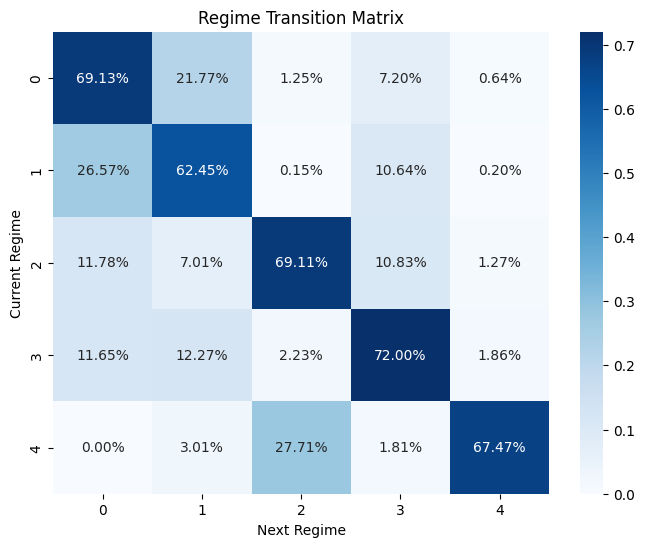

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(trans_matrix, annot=True, fmt=".2%", cmap="Blues")
plt.title("Regime Transition Matrix")
plt.xlabel("Next Regime")
plt.ylabel("Current Regime")
plt.show()

In [35]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import log_loss, make_scorer

tscv = TimeSeriesSplit(n_splits=3)
H=21

print(labels.shape)
print(X_pca.shape)


y = labels[H:]
X = X_pca[:-H]

model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced"
)


fixed_log_loss = make_scorer(
    log_loss,
    response_method="predict_proba",
    greater_is_better=False,
    labels=[0, 1, 2, 3, 4]
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=tscv,
    scoring=fixed_log_loss
)

display(scores)
display(scores.mean())

(6640,)
(6640, 21)


array([-4.3884681 , -0.92732495, -1.27192313])

np.float64(-2.195905390618748)

In [36]:
model.fit(X, y)

# Latest current state
X_current = X_pca[-1].reshape(1, -1)

# Predict regime probabilities H days ahead
current_probs = model.predict_proba(X_current)

# Put into readable table
prob_table = pd.DataFrame(
    current_probs,
    columns=[f"Regime {c}" for c in model.classes_]
).T

prob_table.columns = [f"Probability of regime in {H} trading days"]
prob_table.style.format("{:.3%}")

,Probability of regime in 21 trading days
Regime 0,55.970%
Regime 1,3.210%
Regime 2,34.086%
Regime 3,5.534%
Regime 4,1.201%


In [38]:
regime_names = {
    0: "Strong Expansion / Risk-On",
    1: "Steady Growth / Tightening",
    2: "Inflationary Expansion",
    3: "Risk-Off Slowdown",
    4: "Crisis / Dislocation"
}

prob_table = pd.DataFrame({
    "Regime": model.classes_,
    "Label": [regime_names[c] for c in model.classes_],
    f"Probability in {H} trading days": current_probs[0]
})

prob_table.sort_values(
    f"Probability in {H} trading days",
    ascending=False
).style.format({f"Probability in {H} trading days": "{:.2%}"})

,Regime,Label,Probability in 21 trading days
0,0,Strong Expansion / Risk-On,55.97%
2,2,Inflationary Expansion,34.09%
3,3,Risk-Off Slowdown,5.53%
1,1,Steady Growth / Tightening,3.21%
4,4,Crisis / Dislocation,1.20%


In [41]:
import numpy as np
from sklearn.metrics import log_loss



for cw in [None, "balanced"]:
    model = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        class_weight=cw
    )
    scores = cross_val_score(
        model, X, y,
        cv=tscv,
        scoring=fixed_log_loss
    )
    print(cw, scores.mean())

base_rate = pd.Series(y).value_counts(normalize=True).sort_index()

# unconditional probs
base_probs = np.tile(base_rate.values, (len(y), 1))

baseline_loss = log_loss(y, base_probs)*(-1)
print("Baseline:",baseline_loss)

None -2.071533190315949
balanced -2.195905390618748
Baseline: -1.316316817510703


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "logistic": LogisticRegression(
        solver="lbfgs",
        max_iter=1000
    ),

    "rf": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ),

    "gbm": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "knn": KNeighborsClassifier(
        n_neighbors=20
    )
}

results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=tscv,
        scoring=fixed_log_loss
    )

    results[name] = scores.mean()

    print(name, scores.mean())


logistic -2.071533190315949
rf -1.3329739891493688
gbm -1.6276866275544741
knn -4.635122993377699
